# 💰 Customer Lifetime Value (LTV) Calculation

In this notebook, we will estimate the Lifetime Value (LTV) of our customers.
LTV tells us the total revenue we can expect from a customer over their entire relationship with our company.

**Why is this important?**
If a customer is predicted to Churn, we shouldn't spend \$500 to retain them if their LTV is only \$100. By calculating LTV, we can segment our users into **High, Medium, and Low Value** buckets to prioritize marketing budgets!

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.feature_engineering import create_features
from src.ltv_model import calculate_simple_ltv, segment_customers, train_ltv_regression, save_ltv_model

plt.style.use('seaborn-v0_8-darkgrid')

# Load and prepare data
df = pd.read_csv("../data/raw/telco_customer_churn.csv")
df_featured = create_features(df)

2026-08-21 23:05:57 │ feature_engineering  │ INFO     │ ⚙️  Creating new features...


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ avg_monthly_charge


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ tenure_group


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ is_long_term


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ total_services


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ has_premium_support


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ charge_tenure_ratio


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ is_autopay


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │     ✅ has_streaming


2026-08-21 23:05:57 │ feature_engineering  │ INFO     │ 📊 Total features after engineering: 29


## 1. Calculate Historical & Predicted LTV
We will estimate the remaining lifespan of a customer based on their contract type and current tenure, and use this to project their Total LTV.

2026-08-21 23:05:57 │ ltv_model            │ INFO     │ 💰 Calculating Customer Lifetime Value...


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     Average Historical LTV:  $2279.58


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     Average Predicted LTV:   $356.55


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     Average Total LTV:       $2636.13


2026-08-21 23:05:57 │ ltv_model            │ INFO     │ 📊 Segmenting customers by LTV...


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     Medium Value: 4225 customers (avg LTV: $2123.96)


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     Low Value: 1409 customers (avg LTV: $627.53)


2026-08-21 23:05:57 │ ltv_model            │ INFO     │     High Value: 1409 customers (avg LTV: $6180.53)


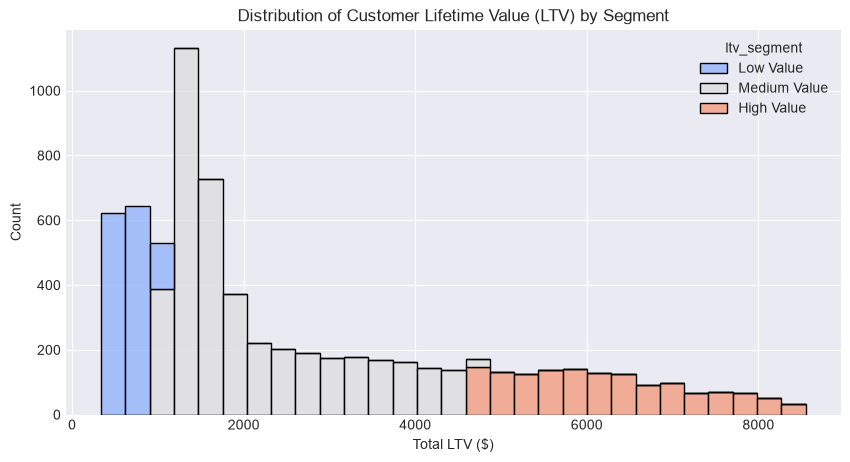

In [2]:
df_ltv = calculate_simple_ltv(df_featured)
df_ltv = segment_customers(df_ltv)

# Let's visualize the distribution of Total LTV
plt.figure(figsize=(10, 5))
sns.histplot(data=df_ltv, x='total_ltv', hue='ltv_segment', multiple='stack', palette='coolwarm')
plt.title("Distribution of Customer Lifetime Value (LTV) by Segment")
plt.xlabel("Total LTV ($)")
plt.show()

## 2. Train an LTV Regression Model
Now we will train an ML model (Gradient Boosting Regressor) to predict LTV for new customers. We'll save this model so our API can use it.

In [3]:
# Train LTV Model
ltv_model, ltv_metrics = train_ltv_regression(df_ltv)

# Save the model
save_ltv_model(ltv_model, "../models/ltv_model.pkl")

print(f"\nModel saved successfully! Now our FastAPI can serve both Churn and LTV predictions.")

2026-08-21 23:05:58 │ ltv_model            │ INFO     │ 🏋️ Training LTV regression model...


2026-08-21 23:05:58 │ ltv_model            │ INFO     │     MAE:  $176.27


2026-08-21 23:05:58 │ ltv_model            │ INFO     │     RMSE: $333.65


2026-08-21 23:05:58 │ ltv_model            │ INFO     │     R²:   0.9744


2026-08-21 23:05:58 │ ltv_model            │ INFO     │ 💾 LTV model saved to: ../models/ltv_model.pkl



Model saved successfully! Now our FastAPI can serve both Churn and LTV predictions.
